1. VERIFICAÇÃO DO BANCO DE DADOS

In [ ]:
file.exists("/content/exportacao_cargas.csv.gz")

[1] TRUE

2. IMPORTAÇÃO DO BANCO DE DADOS

In [ ]:
dados <- read.csv(
  "/content/exportacao_cargas.csv.gz",
  stringsAsFactors = FALSE,
  check.names = FALSE
)

3. VERIFICANDO SE O BANCO DE DADOS FOI IMPORTADO (LINHAS E COLUNAS)

In [ ]:
dim(dados)

[1] 1097014      16

4. TRANSFORMANDO TOTAL_TONELADAS EM NÚMERO (TIRANDO A VÍRGUAL E COLOCANDO PONTO, (QUALITATIVA CONTÍNUA))

In [ ]:
dados$TOTAL_TONELADAS <- as.numeric(
  gsub(",", ".", dados$TOTAL_TONELADAS)
)

5. CORREÇÃO DE VARIÁVEIS NUMÉRICAS (QUANTITATIVA DISCRETA)

In [ ]:
dados$TOTAL_TEU <- as.integer(dados$TOTAL_TEU)
dados$TOTAL_UNID <- as.integer(dados$TOTAL_UNID)

6. CRIANDO SUBCONJUNTO PARA ANALISAR TOTAL_TEU PARA APENAS CARGA CONTERIZADA

In [ ]:
dados_container <- dados[
  dados$NATUREZA_CARGA == "CARGA CONTEINERIZADA",
]

table(dados_container$NATUREZA_CARGA)
cat("\n")

dim(dados_container)


CARGA CONTEINERIZADA 
              978320 

[1] 978320     16

7. FAZENDO REGRESSÃO LINEAR SIMPLES

In [ ]:
m <- lm(TOTAL_TONELADAS ~ TOTAL_TEU, data = dados_container)
summary(m)


Call:
lm(formula = TOTAL_TONELADAS ~ TOTAL_TEU, data = dados_container)

Residuals:
   Min     1Q Median     3Q    Max 
-40277   -117    -87     67  39613 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1.206e+02  1.310e+00    92.1   <2e-16 ***
TOTAL_TEU   9.341e+00  5.657e-03  1651.4   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1210 on 978318 degrees of freedom
Multiple R-squared:  0.736,	Adjusted R-squared:  0.736 
F-statistic: 2.727e+06 on 1 and 978318 DF,  p-value: < 2.2e-16


8. GRÁFICO QUADRADO COM RETA AJUSTADA

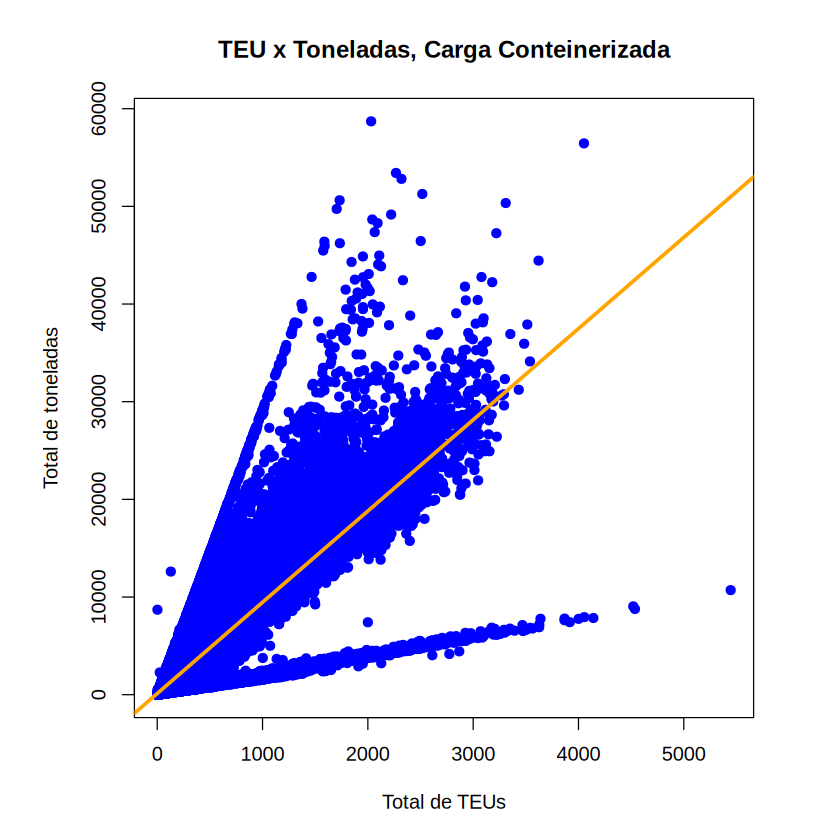

In [ ]:
par(pty = "s")

plot(
  dados_container$TOTAL_TEU, dados_container$TOTAL_TONELADAS,
  pch = 19, col = "blue",
  main = "TEU x Toneladas, Carga Conteinerizada",
  xlab = "Total de TEUs", ylab = "Total de toneladas"
)

abline(m, col = "orange", lwd = 3)

9. FAZENDO REGRESSÃO LINEAR MÚLTIPLA

In [ ]:
m2 <- lm(TOTAL_TONELADAS ~ TOTAL_TEU + TOTAL_UNID, data = dados_container)
summary(m2)


Call:
lm(formula = TOTAL_TONELADAS ~ TOTAL_TEU + TOTAL_UNID, data = dados_container)

Residuals:
   Min     1Q Median     3Q    Max 
-40137    -87    -60     72  28892 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 88.15772    1.27535   69.12   <2e-16 ***
TOTAL_TEU    1.61873    0.03101   52.20   <2e-16 ***
TOTAL_UNID  13.01724    0.05144  253.03   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1172 on 978317 degrees of freedom
Multiple R-squared:  0.7522,	Adjusted R-squared:  0.7522 
F-statistic: 1.485e+06 on 2 and 978317 DF,  p-value: < 2.2e-16


10. DIAGNÓSTICO DOS RESÍDUOS

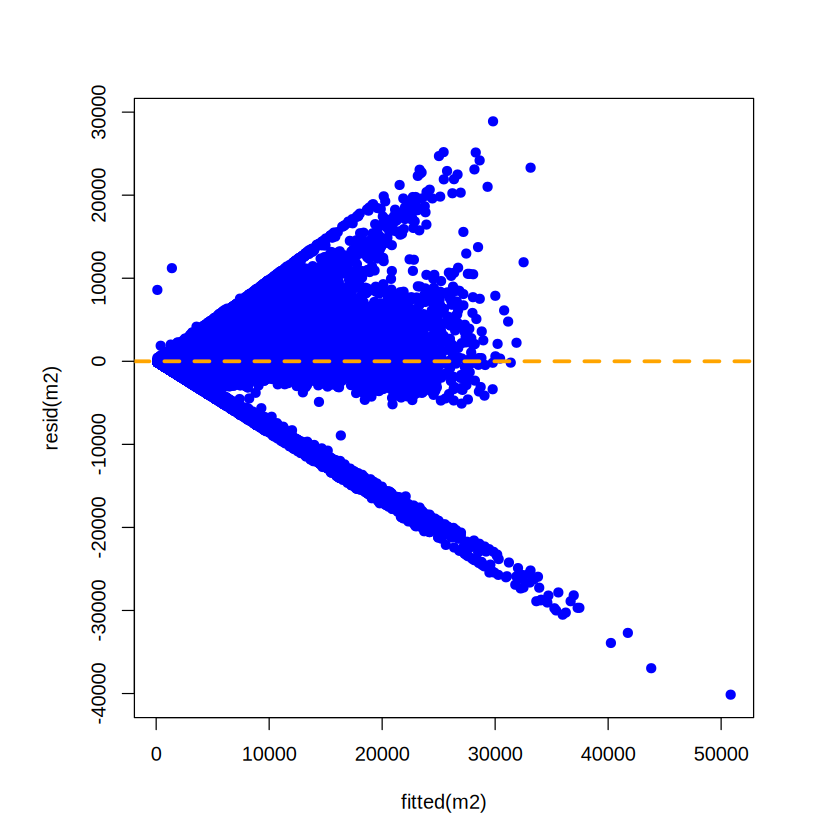

In [ ]:
par(pty = "s")

plot(fitted(m2), resid(m2), pch = 19, col = "blue")
abline(h = 0, col = "orange", lwd = 3, lty = 2)

11. APLICANDO LOG

12. TRANSFORMAÇÃO

In [ ]:
dados_container$log_TEU <- log(dados_container$TOTAL_TEU)
dados_container$log_TONELADAS <- log(dados_container$TOTAL_TONELADAS)

13. REGRESSÃO COM VARIÁVEIS EM LOG

In [ ]:
m_log <- lm(log_TONELADAS ~ log_TEU, data = dados_container)
summary(m_log)  # b0, b1, p-valor, R²


Call:
lm(formula = log_TONELADAS ~ log_TEU, data = dados_container)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.5459 -0.1826  0.2439  0.4993  5.7475 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 2.6925797  0.0013099    2056   <2e-16 ***
log_TEU     0.9103421  0.0004052    2247   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7445 on 978318 degrees of freedom
Multiple R-squared:  0.8377,	Adjusted R-squared:  0.8377 
F-statistic: 5.048e+06 on 1 and 978318 DF,  p-value: < 2.2e-16


14. GRÁFICO QUADRADO COM RETA EM LOG

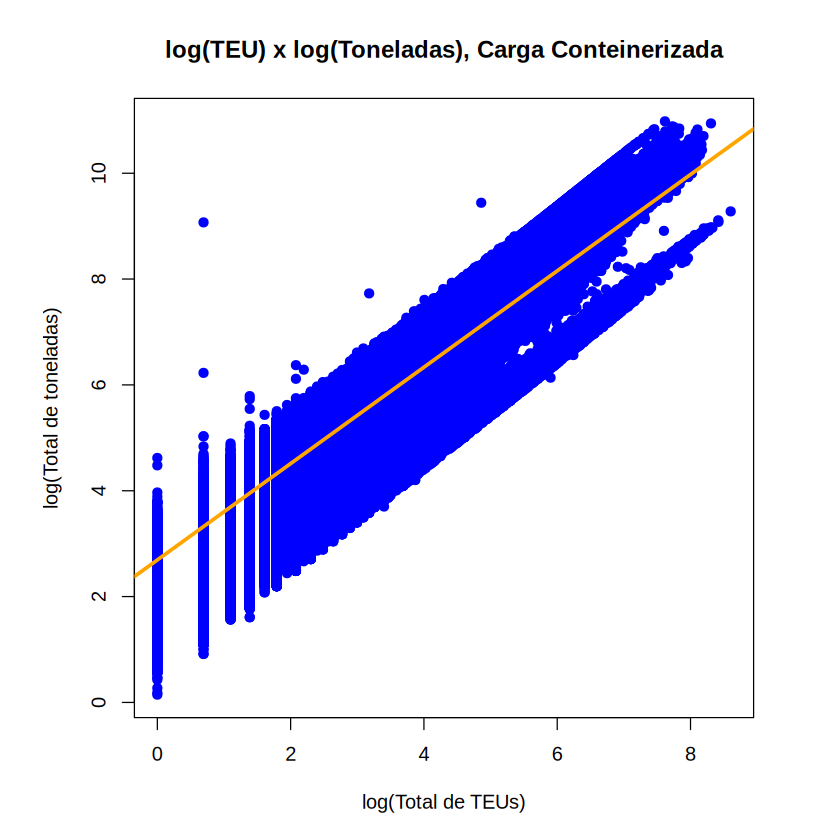

In [ ]:
par(pty = "s")

plot(
  dados_container$log_TEU, dados_container$log_TONELADAS,
  pch = 19, col = "blue",
  main = "log(TEU) x log(Toneladas), Carga Conteinerizada",
  xlab = "log(Total de TEUs)", ylab = "log(Total de toneladas)"
)

abline(m_log, col = "orange", lwd = 3)

15. DIAGNÓSTICO COM RESÍDUOS EM LOG

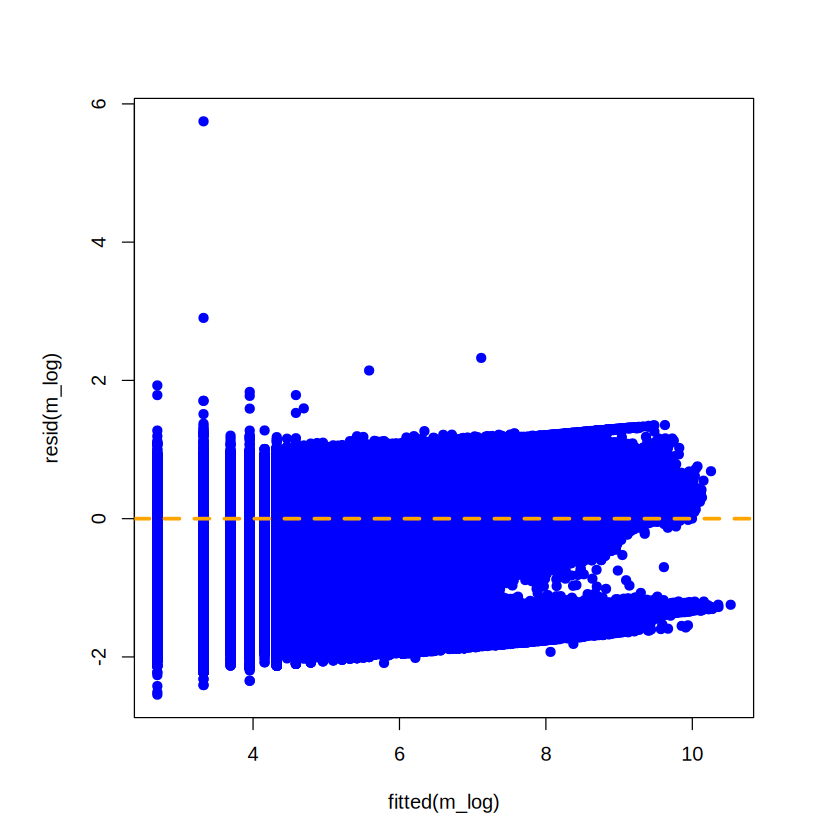

In [ ]:
par(pty = "s")

plot(fitted(m_log), resid(m_log), pch = 19, col = "blue")
abline(h = 0, col = "orange", lwd = 3, lty = 2)

16. COMPARANDO O R² DOS DOIS MODELOS

In [ ]:
cat("R² modelo original:", summary(m)$r.squared, "\n")
cat("R² modelo em log:", summary(m_log)$r.squared, "\n")

R² modelo original: 0.7359829 
R² modelo em log: 0.8376624 


17. INSTALANDO E CARREGANDO PACOTE IMTEST

In [ ]:
install.packages("lmtest")
library(lmtest)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



18. TESTANDO BREUSCH-PAGAN NO MODELO ORIGINAL

In [ ]:
bptest(m)


	studentized Breusch-Pagan test

data:  m
BP = 238594, df = 1, p-value < 2.2e-16


19. TESTANDO BREUSCH-PAGAN NO MODELO EM LOG

In [ ]:
bptest(m_log)


	studentized Breusch-Pagan test

data:  m_log
BP = 20359, df = 1, p-value < 2.2e-16


20. SELECIONANDO AS VARIÁVEIS PARA O MODELO

In [ ]:
dados_modelo <- dados[, c(
  "TOTAL_TONELADAS", "TOTAL_TEU", "TOTAL_UNID",
  "TIPO_NAVEGACAO", "MOVIMENTO", "ANO", "TERMINAIS",
  "NATUREZA_CARGA", "MES", "CLASSENAVIO", "SENTIDO",
  "TIPO_INSTALACAO", "BERCOS", "MERCADORIAS"
)]

dados_modelo$y <- dados_modelo$TOTAL_TONELADAS
dados_modelo$TOTAL_TONELADAS <- NULL

21. TRABALHANDO COM UMA AMOSTRA

In [ ]:
set.seed(123)
amostra <- dados_modelo[sample(nrow(dados_modelo), 8000), ]

22. INSTALANDO E CARREGANDO O GLMNET

In [ ]:
install.packages("glmnet")
library(glmnet)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



23. MONTANDO A MATRIZ X E O VETOR Y

In [ ]:
X <- model.matrix(y ~ ., data = amostra)[, -1]
yv <- amostra$y

24. LASSO E RIDGE COM VALIDAÇÃO CRUZADA

In [ ]:
set.seed(1)
cvl <- cv.glmnet(X, yv, alpha = 1)
cvr <- cv.glmnet(X, yv, alpha = 0)

25. CURVA EM U DO LASSO

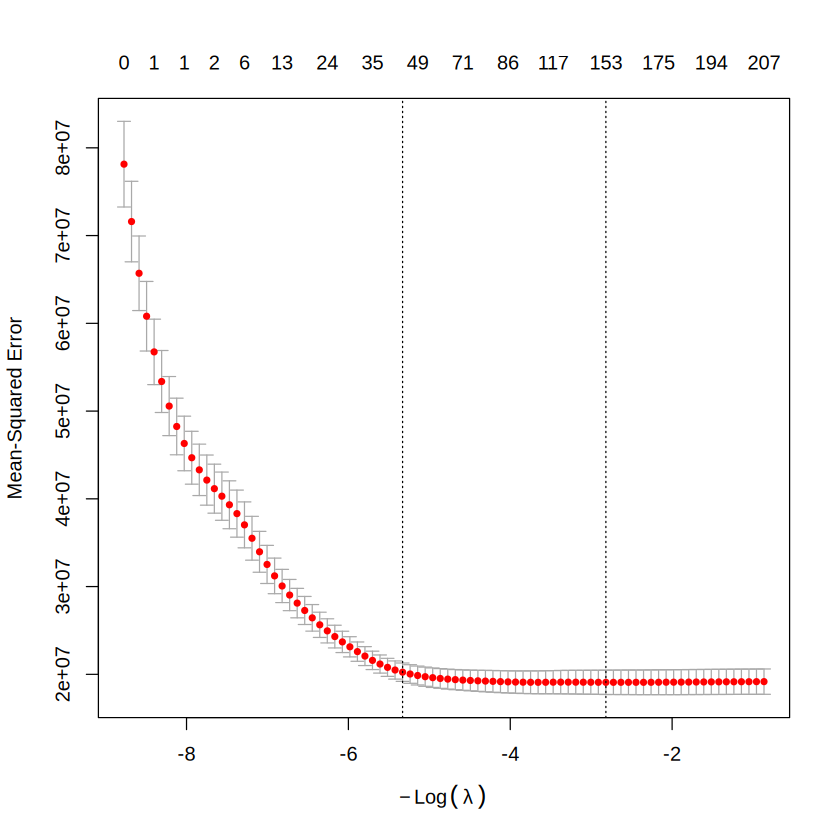

In [ ]:
plot(cvl)

26. PREDITORES QUE SOBREVIVERAM NO LASSO

In [ ]:
cl <- coef(cvl, s = "lambda.1se")
cl[as.vector(cl) != 0, ]

(Intercept)                            TOTAL_TEU 
                       -28782.675990                             8.373055 
                                 ANO                         TERMINAISADM 
                           14.907041                         20257.962201 
                    TERMINAISBRACELL                   TERMINAISCITROSUCO 
                        22247.133586                          7378.619551 
   TERMINAISCLI SUL (ELEVAÇÕES/RUMO)                     TERMINAISCUTRALE 
                        11429.540600                          2669.837057 
                        TERMINAISNST TERMINAISSUZANO (VCP - ARM 13/14/15) 
                          829.034579                          1642.184694 
             TERMINAISTERMINAL XXXIX                         TERMINAISTES 
                        12272.010447                         24149.670561 
                        TERMINAISTGG                  TERMINAISTRANSPETRO 
                        23156.847173                          4859.231962 
                   TERMINAISUSIMINAS         NATUREZA_CARGAGRANEL LIQUIDO 
                         1535.397868                          3277.687822 
         NATUREZA_CARGAGRANEL SOLIDO                CLASSENAVIOGRANELEIRO 
                        19452.753350                          3658.181632 
         CLASSENAVIOPORTA-CONTAINERS                    CLASSENAVIOTANQUE 
                         -969.731006                          1243.648439 
                     SENTIDOEMBARQUE                          BERCOSAL 01 
                          100.646853                          1149.603101 
                     BERCOSARM 13/14                      BERCOSARM 16/17 
                        -5867.763938                          7011.326950 
                     BERCOSARM 20/21                         BERCOSARM 38 
                        16825.920101                         -8538.835349 
                        BERCOSARM 39                        BERCOSCUTRALE 
                          644.122384                            25.028645 
                         BERCOSDPW 4                         BERCOSOUT. 3 
                        19092.018440                         27317.456827 
                           BERCOSTEG                       BERCOSTIPLAM 2 
                        14468.521019                         17164.431547 
                      BERCOSTIPLAM 3                     BERCOSUSIMINAS 1 
                         8695.421187                          1815.472314 
   MERCADORIASBUNKER (O.COMBUSTIVEL)                  MERCADORIASCELULOSE 
                        58881.367714                            95.589029 
                  MERCADORIASENXOFRE                     MERCADORIASMILHO 
                          522.803819                          3910.951321 
         MERCADORIASÓLEO COMBUSTÍVEL               MERCADORIASÓLEO DIESEL 
                        21852.496287                          7077.293366 
               MERCADORIASSEM CARGAS             MERCADORIASSOJA EM GRÃOS 
                         -915.294438                          9928.934793

27. COMPARANDO O ERRO DE CV ENTRE LASSO E RIDGE

In [ ]:
c(lasso = min(cvl$cvm), ridge = min(cvr$cvm))

lasso    ridge 
19089879 18642481